In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

/tmp/ipykernel_1427480/1814426599.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior /= np.trapz(posterior, x)  # Normalize to make it a valid probability distribution


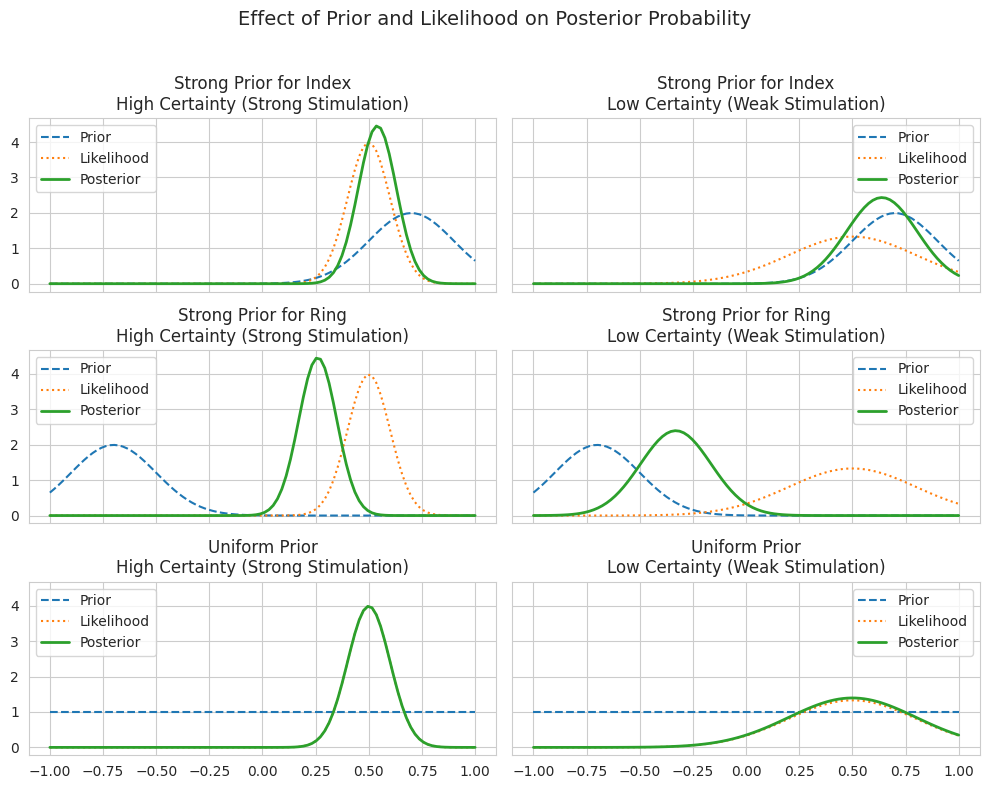

In [3]:

def bayesian_update(prior, likelihood, x):
    posterior = prior * likelihood
    posterior /= np.trapz(posterior, x)  # Normalize to make it a valid probability distribution
    return posterior

# Define a range of possible hypotheses (which finger was perturbed)
x = np.linspace(-1, 1, 100)  # -1 = ring finger, 1 = index finger

# Define different priors (reflecting different probability cues)
priors = {
    "Strong Prior for Index": norm.pdf(x, loc=0.7, scale=0.2),
    "Strong Prior for Ring": norm.pdf(x, loc=-0.7, scale=0.2),
    "Uniform Prior": np.ones_like(x)
}

# Define different likelihoods (reflecting different stimulation intensities)
likelihoods = {
    "High Certainty (Strong Stimulation)": norm.pdf(x, loc=0.5, scale=0.1),
    "Low Certainty (Weak Stimulation)": norm.pdf(x, loc=0.5, scale=0.3)
}

# Plot the effects of different priors and likelihoods
fig, axes = plt.subplots(len(priors), len(likelihoods), figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle("Effect of Prior and Likelihood on Posterior Probability", fontsize=14)

for i, (prior_label, prior) in enumerate(priors.items()):
    for j, (likelihood_label, likelihood) in enumerate(likelihoods.items()):
        posterior = bayesian_update(prior, likelihood, x)

        axes[i, j].plot(x, prior, label="Prior", linestyle="dashed")
        axes[i, j].plot(x, likelihood, label="Likelihood", linestyle="dotted")
        axes[i, j].plot(x, posterior, label="Posterior", linewidth=2)

        axes[i, j].set_title(f"{prior_label}\n{likelihood_label}")
        axes[i, j].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
